# Simple and rudimentary visualisations for mediapipe HPE results

04/18/2026 | 
Author: Cristian Ortega Singer | 
Mail: cris.ortega@fau.de


Inspect structure of a single file

In [1]:
import pandas as pd
from pathlib import Path

parquet_path = Path("../data/derived/mediapipe_pose/2015-02-23_kLLyjW96Ez0.parquet")
video_path = "../data/source_videos/2015-02-23_kLLyjW96Ez0.mp4"

df = pd.read_parquet(parquet_path)
df.head()





,video,frame_idx,timestamp_ms,landmark_id,x,y,z,visibility,presence,world_x,world_y,world_z
0,2015-02-23_kLLyjW96Ez0.mp4,156,6240,0,0.408019,0.307734,0.121019,0.983063,0.999835,-0.327699,-0.215610,0.125788
1,2015-02-23_kLLyjW96Ez0.mp4,156,6240,1,0.401958,0.301713,0.126617,0.952709,0.999794,-0.345752,-0.227740,0.133403
2,2015-02-23_kLLyjW96Ez0.mp4,156,6240,2,0.401514,0.299735,0.126490,0.939151,0.999818,-0.343695,-0.228904,0.139700
3,2015-02-23_kLLyjW96Ez0.mp4,156,6240,3,0.401322,0.297878,0.126552,0.956605,0.999766,-0.345629,-0.229126,0.136431
4,2015-02-23_kLLyjW96Ez0.mp4,156,6240,4,0.402475,0.306045,0.128501,0.969476,0.999757,-0.350166,-0.236305,0.121022


Plot of vertical motion of right wrist movement

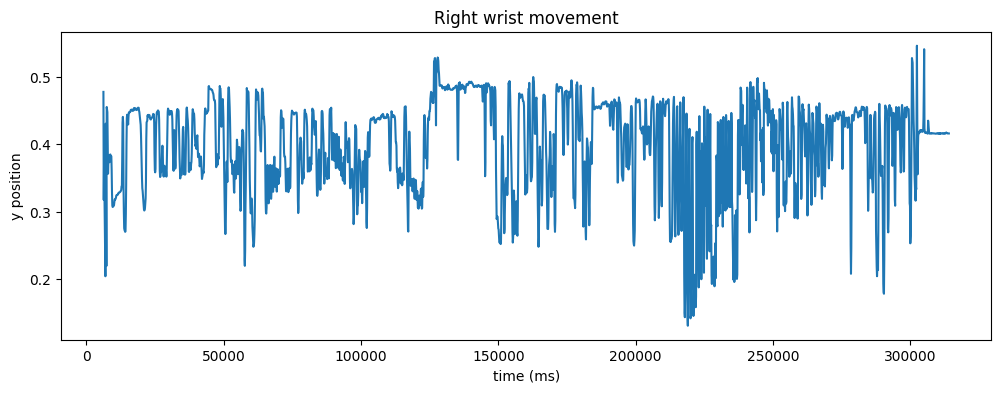

In [2]:
import matplotlib.pyplot as plt

right_wrist = df[df.landmark_id == 16]

plt.figure(figsize=(12,4))
plt.plot(right_wrist.timestamp_ms, right_wrist.y)
plt.xlabel("time (ms)")
plt.ylabel("y position")
plt.title("Right wrist movement")
plt.show()

Plot of vertical motion of left wrist movement

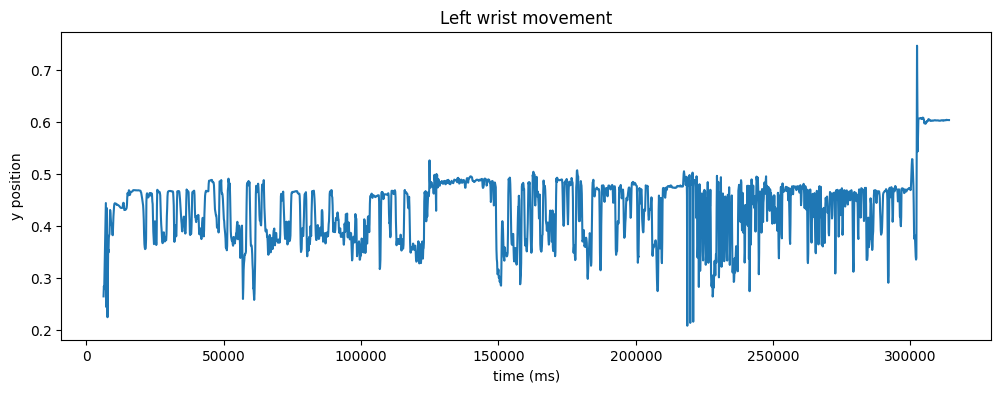

In [3]:
import matplotlib.pyplot as plt

left_wrist = df[df.landmark_id == 15]

plt.figure(figsize=(12,4))
plt.plot(right_wrist.timestamp_ms, left_wrist.y)
plt.xlabel("time (ms)")
plt.ylabel("y position")
plt.title("Left wrist movement")
plt.show()

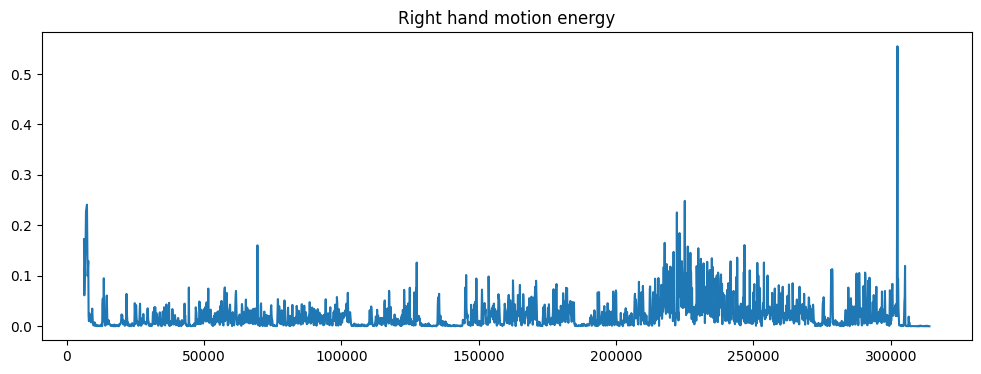

In [4]:
import numpy as np

right_wrist = df[df.landmark_id == 16].copy()

right_wrist["dx"] = right_wrist.x.diff()
right_wrist["dy"] = right_wrist.y.diff()

right_wrist["velocity"] = np.sqrt(
    right_wrist.dx**2 + right_wrist.dy**2
)

plt.figure(figsize=(12,4))
plt.plot(right_wrist.timestamp_ms, right_wrist.velocity)
plt.title("Right hand motion energy")
plt.show()

Create video overlay (without interpolation)

In [6]:
import cv2
import pandas as pd
from pathlib import Path

# --- MediaPipe pose connections (main body) ---
connections = [
    (0, 1), (1, 2), (2, 3), (3, 7),      # face left
    (0, 4), (4, 5), (5, 6), (6, 8),      # face right
    (9, 10),                              # mouth
    (11, 12),                             # shoulders
    (11, 13), (13, 15),                   # left arm
    (12, 14), (14, 16),                   # right arm
    (15, 17), (15, 19), (15, 21),         # left hand
    (16, 18), (16, 20), (16, 22),         # right hand
    (11, 23), (12, 24),                   # torso
    (23, 24),                             # hips
    (23, 25), (25, 27), (27, 29), (29, 31),  # left leg
    (24, 26), (26, 28), (28, 30), (30, 32),  # right leg
    (27, 31), (28, 32)                    # feet
]

# --- open video ---
cap = cv2.VideoCapture(str(video_path))

fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 25.0

delay = int(1000 / fps)  # milliseconds per frame

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    pose = df[df.frame_idx == frame_idx]

    # build lookup: landmark_id -> (x_px, y_px)
    coords = {}
    for _, row in pose.iterrows():
        if pd.notna(row["x"]) and pd.notna(row["y"]):
            x_px = int(row["x"] * w)
            y_px = int(row["y"] * h)
            coords[int(row["landmark_id"])] = (x_px, y_px)

    # draw connections first
    for a, b in connections:
        if a in coords and b in coords:
            cv2.line(frame, coords[a], coords[b], (0, 255, 0), 2)

    # draw landmark points on top
    for landmark_id, (x_px, y_px) in coords.items():
        cv2.circle(frame, (x_px, y_px), 4, (0, 0, 255), -1)

    # show frame number
    cv2.putText(
        frame,
        f"frame: {frame_idx}",
        (20, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.imshow("MediaPipe Overlay", frame)

    key = cv2.waitKey(delay) & 0xFF
    if key == 27:   # ESC
        break
    elif key == ord("q"):
        break

    frame_idx += 1

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

Run rudimentary interpolation

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path


df = df.sort_values(["landmark_id", "frame_idx"]).copy()
df.head()

def interpolate_pose_df(df):
    df = df.copy()

    id_cols = ["video", "landmark_id"]
    value_cols = ["x", "y", "z", "world_x", "world_y", "world_z", "visibility", "presence"]

    all_parts = []

    for (video, landmark_id), group in df.groupby(id_cols):
        group = group.sort_values("frame_idx").copy()
        group["is_original"] = True

        full_frames = pd.DataFrame({
            "frame_idx": np.arange(group["frame_idx"].min(), group["frame_idx"].max() + 1)
        })

        merged = full_frames.merge(group, on="frame_idx", how="left")
        merged["video"] = video
        merged["landmark_id"] = landmark_id
        merged["is_original"] = merged["is_original"].fillna(False)

        if "timestamp_ms" in merged.columns:
            merged["timestamp_ms"] = merged["timestamp_ms"].interpolate(method="linear")

        for col in value_cols:
            if col in merged.columns:
                merged[col] = merged[col].interpolate(method="linear", limit_area="inside")

        all_parts.append(merged)

    out = pd.concat(all_parts, ignore_index=True)

    preferred_order = [
        "video", "frame_idx", "timestamp_ms", "landmark_id",
        "x", "y", "z",
        "world_x", "world_y", "world_z",
        "visibility", "presence", "is_original"
    ]
    existing = [c for c in preferred_order if c in out.columns]
    remaining = [c for c in out.columns if c not in existing]
    return out[existing + remaining]


df_interp = interpolate_pose_df(df)

print("Original rows:", len(df))
print("Interpolated rows:", len(df_interp))

print("Original frames:", df.frame_idx.nunique())
print("Interpolated frames:", df_interp.frame_idx.nunique())

out_path = Path("../data/derived/mediapipe_pose_interpolated/example_interpolated.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

df_interp.to_parquet(out_path, index=False)

Original rows: 84447
Interpolated rows: 253968
Original frames: 2559
Interpolated frames: 7696


In [8]:
import cv2
import pandas as pd
from pathlib import Path

# --- MediaPipe pose connections (main body) ---
connections = [
    (0, 1), (1, 2), (2, 3), (3, 7),      # face left
    (0, 4), (4, 5), (5, 6), (6, 8),      # face right
    (9, 10),                              # mouth
    (11, 12),                             # shoulders
    (11, 13), (13, 15),                   # left arm
    (12, 14), (14, 16),                   # right arm
    (15, 17), (15, 19), (15, 21),         # left hand
    (16, 18), (16, 20), (16, 22),         # right hand
    (11, 23), (12, 24),                   # torso
    (23, 24),                             # hips
    (23, 25), (25, 27), (27, 29), (29, 31),  # left leg
    (24, 26), (26, 28), (28, 30), (30, 32),  # right leg
    (27, 31), (28, 32)                    # feet
]

# --- open video ---
cap = cv2.VideoCapture(str(video_path))

fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 25.0

delay = int(1000 / fps)  # milliseconds per frame

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w, _ = frame.shape
    pose = df_interp[df_interp.frame_idx == frame_idx]

    # build lookup: landmark_id -> (x_px, y_px)
    coords = {}
    for _, row in pose.iterrows():
        if pd.notna(row["x"]) and pd.notna(row["y"]):
            x_px = int(row["x"] * w)
            y_px = int(row["y"] * h)
            coords[int(row["landmark_id"])] = (x_px, y_px)

    # draw connections first
    for a, b in connections:
        if a in coords and b in coords:
            cv2.line(frame, coords[a], coords[b], (0, 255, 0), 2)

    # draw landmark points on top
    for landmark_id, (x_px, y_px) in coords.items():
        cv2.circle(frame, (x_px, y_px), 4, (0, 0, 255), -1)

    # show frame number
    cv2.putText(
        frame,
        f"frame: {frame_idx}",
        (20, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.imshow("MediaPipe Overlay", frame)

    key = cv2.waitKey(delay) & 0xFF
    if key == 27:   # ESC
        break
    elif key == ord("q"):
        break

    frame_idx += 1

cap.release()
cv2.destroyAllWindows()